Loading gl2021.txt...
Loading gl2022.txt...
Loading gl2023.txt...
Loading gl2024.txt...
Loading gl2025.txt...

All MLB games shape: (12143, 16)

MLB home games shape: (12143, 12)


,game_date,season,team_abbr,team,opponent_abbr,result,attendance,weekday,month,weekend_game,day_night,park_id
0,2021-04-01,2021,CHN,Chicago Cubs,PIT,L,10343.0,Thursday,April,0,D,CHI11
1,2021-04-01,2021,CIN,Cincinnati Reds,SLN,L,12264.0,Thursday,April,0,D,CIN09
2,2021-04-01,2021,COL,Colorado Rockies,LAN,W,20570.0,Thursday,April,0,D,DEN02
3,2021-04-01,2021,MIA,Miami Marlins,TBA,L,7062.0,Thursday,April,0,D,MIA02
4,2021-04-01,2021,MIL,Milwaukee Brewers,MIN,W,11740.0,Thursday,April,0,D,MIL06



Guardians home games shape: (403, 12)


,game_date,season,team_abbr,team,opponent_abbr,result,attendance,weekday,month,weekend_game,day_night,park_id
0,2021-04-05,2021,CLE,Cleveland Guardians,KCA,L,8914.0,Monday,April,0,D,CLE08
1,2021-04-07,2021,CLE,Cleveland Guardians,KCA,W,5908.0,Wednesday,April,0,D,CLE08
2,2021-04-09,2021,CLE,Cleveland Guardians,DET,W,7775.0,Friday,April,1,N,CLE08
3,2021-04-10,2021,CLE,Cleveland Guardians,DET,W,7570.0,Saturday,April,1,N,CLE08
4,2021-04-11,2021,CLE,Cleveland Guardians,DET,W,6859.0,Sunday,April,1,D,CLE08



Saved:
- mlb_home_games.csv
- guardians_home_games.csv

Seasons in MLB dataset:
season
2021    2429
2022    2429
2023    2428
2024    2428
2025    2429
Name: count, dtype: int64

Seasons in Guardians dataset:
season
2021    81
2022    81
2023    80
2024    80
2025    81
Name: count, dtype: int64

Average Guardians attendance by season:
season
2021    13758.0
2022    15998.0
2023    22926.0
2024    25703.0
2025    25325.0
Name: attendance, dtype: float64


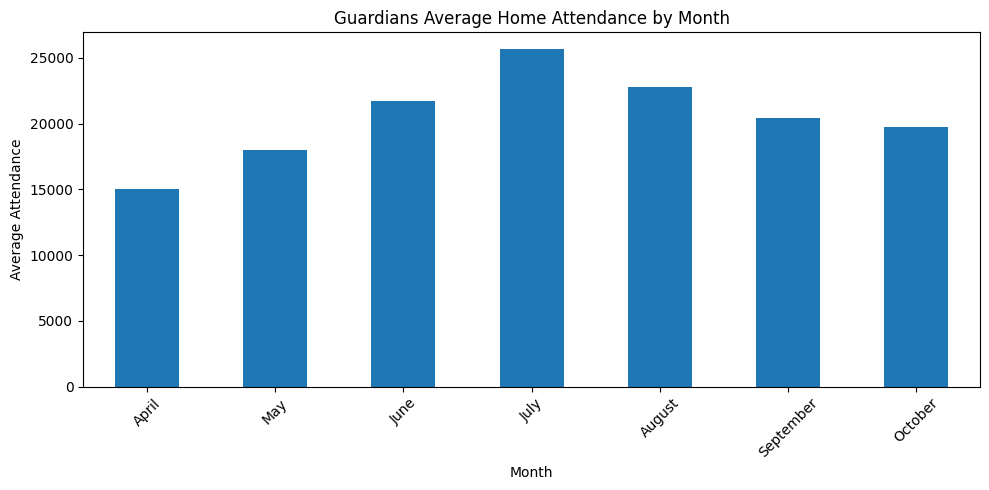

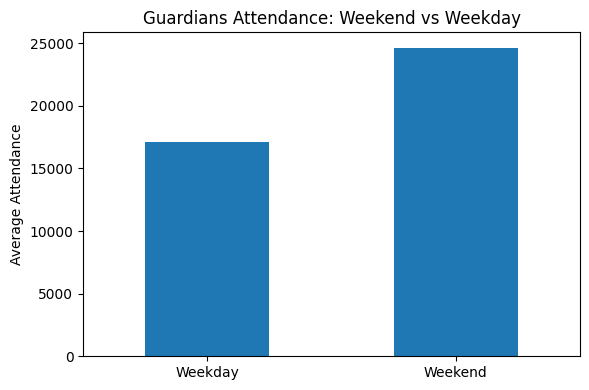

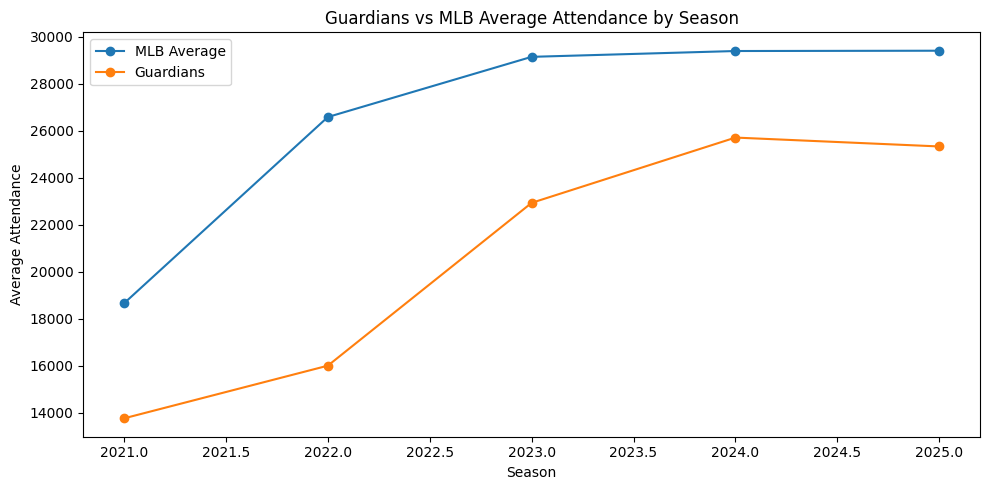

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io
import os

# =====================================================
# 1. UPLOAD YOUR RETROSHEET GAME LOG FILES
# =====================================================
# Upload files like:

files = {
    2021: "gl2021.txt",
    2022: "gl2022.txt",
    2023: "gl2023.txt",
    2024: "gl2024.txt",
    2025: "gl2025.txt"
}

# =====================================================
# 2. COLUMN MAP FOR THE FIELDS WE NEED
# =====================================================
# Retrosheet game logs have no header row.
# These are the key columns we need for attendance analysis.

COLUMN_MAP = {
    0: "date",
    3: "away_team",
    6: "home_team",
    9: "away_score",
    10: "home_score",
    11: "game_length_outs",
    12: "day_night",
    16: "park_id",
    17: "attendance"
}

# Optional full team name map for nicer labels
TEAM_NAME_MAP = {
    "ARI": "Arizona Diamondbacks",
    "ATL": "Atlanta Braves",
    "BAL": "Baltimore Orioles",
    "BOS": "Boston Red Sox",
    "CHN": "Chicago Cubs",
    "CHA": "Chicago White Sox",
    "CIN": "Cincinnati Reds",
    "CLE": "Cleveland Guardians",
    "COL": "Colorado Rockies",
    "DET": "Detroit Tigers",
    "HOU": "Houston Astros",
    "KCA": "Kansas City Royals",
    "ANA": "Los Angeles Angels",
    "LAN": "Los Angeles Dodgers",
    "MIA": "Miami Marlins",
    "MIL": "Milwaukee Brewers",
    "MIN": "Minnesota Twins",
    "NYN": "New York Mets",
    "NYA": "New York Yankees",
    "ATH": "Athletics",
    "PHI": "Philadelphia Phillies",
    "PIT": "Pittsburgh Pirates",
    "SDN": "San Diego Padres",
    "SFN": "San Francisco Giants",
    "SEA": "Seattle Mariners",
    "SLN": "St. Louis Cardinals",
    "TBA": "Tampa Bay Rays",
    "TEX": "Texas Rangers",
    "TOR": "Toronto Blue Jays",
    "WAS": "Washington Nationals"
}

# =====================================================
# 3. FUNCTION TO LOAD ONE RETROSHEET FILE
# =====================================================
def load_retrosheet_file(filepath):
    """
    Load a Retrosheet game log TXT file and keep only
    the columns needed for attendance analysis.
    """
    df = pd.read_csv(filepath, header=None)

    # Keep only the columns we need
    keep_idx = list(COLUMN_MAP.keys())
    df = df[keep_idx].copy()

    # Rename columns
    df = df.rename(columns=COLUMN_MAP)

    # Clean date and attendance
    df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
    df["attendance"] = pd.to_numeric(df["attendance"], errors="coerce")
    df["away_score"] = pd.to_numeric(df["away_score"], errors="coerce")
    df["home_score"] = pd.to_numeric(df["home_score"], errors="coerce")
    df["game_length_outs"] = pd.to_numeric(df["game_length_outs"], errors="coerce")

    # Add season from date
    df["season"] = df["date"].dt.year

    # Create result from home team perspective
    df["home_result"] = (df["home_score"] > df["away_score"]).map({True: "W", False: "L"})

    # Time features
    df["weekday"] = df["date"].dt.day_name()
    df["month"] = df["date"].dt.month_name()
    df["weekend_game"] = df["weekday"].isin(["Friday", "Saturday", "Sunday"]).astype(int)

    # Team name labels
    df["home_team_name"] = df["home_team"].map(TEAM_NAME_MAP)
    df["away_team_name"] = df["away_team"].map(TEAM_NAME_MAP)

    # Drop bad rows
    df = df.dropna(subset=["date", "attendance", "home_team", "away_team"]).copy()

    return df

# =====================================================
# 4. LOAD ALL UPLOADED FILES
# =====================================================
all_files = []

for season, filename in files.items():
    try:
        print(f"Loading {filename}...")

        temp = load_retrosheet_file(filename)
        temp["season"] = season

        all_files.append(temp)

    except Exception as e:
        print(f"Error loading {filename}: {e}")

mlb_games = pd.concat(all_files, ignore_index=True)
mlb_games = mlb_games.sort_values(["season", "date"]).reset_index(drop=True)

print("\nAll MLB games shape:", mlb_games.shape)
mlb_games.head()

# =====================================================
# 5. CREATE MAIN HOME-GAME DATASET
# =====================================================
# In Retrosheet, each row is already one game.
# Attendance belongs to the HOME team for that row.

mlb_home_games = mlb_games.copy()

# Rename for a cleaner final dataset
mlb_home_games = mlb_home_games.rename(columns={
    "date": "game_date",
    "home_team": "team_abbr",
    "home_team_name": "team",
    "away_team": "opponent_abbr",
    "away_team_name": "opponent",
    "home_score": "team_score",
    "away_score": "opponent_score",
    "home_result": "result"
})

mlb_home_games = mlb_home_games[
    [
        "game_date",
        "season",
        "team_abbr",
        "team",
        "opponent_abbr",
        "result",
        "attendance",
        "weekday",
        "month",
        "weekend_game",
        "day_night",
        "park_id"
    ]
].copy()

print("\nMLB home games shape:", mlb_home_games.shape)
display(mlb_home_games.head())

# =====================================================
# 6. CREATE GUARDIANS HOME DATASET
# =====================================================
guardians_home_games = mlb_home_games[mlb_home_games["team_abbr"] == "CLE"].copy()
guardians_home_games = guardians_home_games.sort_values(["season", "game_date"]).reset_index(drop=True)

print("\nGuardians home games shape:", guardians_home_games.shape)
display(guardians_home_games.head())

# =====================================================
# 7. SAVE TO CSV
# =====================================================
mlb_home_games.to_csv("mlb_home_games.csv", index=False)
guardians_home_games.to_csv("guardians_home_games.csv", index=False)

print("\nSaved:")
print("- mlb_home_games.csv")
print("- guardians_home_games.csv")

# =====================================================
# 8. QUICK CHECKS
# =====================================================
print("\nSeasons in MLB dataset:")
print(mlb_home_games["season"].value_counts().sort_index())

print("\nSeasons in Guardians dataset:")
print(guardians_home_games["season"].value_counts().sort_index())

print("\nAverage Guardians attendance by season:")
print(guardians_home_games.groupby("season")["attendance"].mean().round(0))

# =====================================================
# 9. STARTER CHART 1: GUARDIANS ATTENDANCE BY MONTH
# =====================================================
month_order = ["March", "April", "May", "June", "July", "August", "September", "October"]

guardians_month_avg = guardians_home_games.groupby("month")["attendance"].mean()
guardians_month_avg = guardians_month_avg.reindex([m for m in month_order if m in guardians_month_avg.index])

plt.figure(figsize=(10, 5))
guardians_month_avg.plot(kind="bar")
plt.title("Guardians Average Home Attendance by Month")
plt.ylabel("Average Attendance")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =====================================================
# 10. STARTER CHART 2: WEEKEND VS WEEKDAY
# =====================================================
weekend_avg = guardians_home_games.groupby("weekend_game")["attendance"].mean()
weekend_avg.index = ["Weekday", "Weekend"]

plt.figure(figsize=(6, 4))
weekend_avg.plot(kind="bar")
plt.title("Guardians Attendance: Weekend vs Weekday")
plt.ylabel("Average Attendance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# =====================================================
# 11. STARTER CHART 3: GUARDIANS VS MLB AVG BY SEASON
# =====================================================
mlb_season_avg = mlb_home_games.groupby("season")["attendance"].mean()
guardians_season_avg = guardians_home_games.groupby("season")["attendance"].mean()

plt.figure(figsize=(10, 5))
plt.plot(mlb_season_avg.index, mlb_season_avg.values, marker="o", label="MLB Average")
plt.plot(guardians_season_avg.index, guardians_season_avg.values, marker="o", label="Guardians")
plt.title("Guardians vs MLB Average Attendance by Season")
plt.xlabel("Season")
plt.ylabel("Average Attendance")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import requests
from io import StringIO
import time

# Spotrac uses standard MLB abbreviations; your Retrosheet data uses some older-style team codes.
spotrac_to_retrosheet = {
    "ARI": "ARI",
    "ATL": "ATL",
    "BAL": "BAL",
    "BOS": "BOS",
    "CHC": "CHN",
    "CHW": "CHA",
    "CIN": "CIN",
    "CLE": "CLE",
    "COL": "COL",
    "DET": "DET",
    "HOU": "HOU",
    "KC":  "KCA",
    "LAA": "ANA",
    "LAD": "LAN",
    "MIA": "MIA",
    "MIL": "MIL",
    "MIN": "MIN",
    "NYM": "NYN",
    "NYY": "NYA",
    "ATH": "ATH",
    "PHI": "PHI",
    "PIT": "PIT",
    "SD":  "SDN",
    "SF":  "SFN",
    "SEA": "SEA",
    "STL": "SLN",
    "TB":  "TBA",
    "TEX": "TEX",
    "TOR": "TOR",
    "WSH": "WAS"
}

headers = {
    "User-Agent": "Mozilla/5.0"
}

def scrape_spotrac_cash_payroll(year: int) -> pd.DataFrame:
    url = f"https://www.spotrac.com/mlb/cash/_/year/{year}"
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()

    tables = pd.read_html(StringIO(r.text))

    # Find the table that contains Team + Total Cash
    payroll_table = None
    for t in tables:
        cols = [str(c) for c in t.columns]
        if ("Team" in cols) and any("Total Cash" in c for c in cols):
            payroll_table = t.copy()
            break

    if payroll_table is None:
        raise ValueError(f"Could not find payroll table for {year}")

    # Standardize column names
    payroll_table.columns = [str(c).strip() for c in payroll_table.columns]

    # Keep likely useful columns
    keep_cols = []
    for c in payroll_table.columns:
        if c in ["Team", "Record", "Signed", "Avg Age Team"]:
            keep_cols.append(c)
        if "Total Cash" in c:
            keep_cols.append(c)

    payroll_table = payroll_table[keep_cols].copy()

    # Rename total cash column
    total_cash_col = [c for c in payroll_table.columns if "Total Cash" in c][0]
    payroll_table = payroll_table.rename(columns={total_cash_col: "payroll"})

    # Clean team code from strings like "LAD LAD"
    payroll_table["spotrac_team_abbr"] = (
        payroll_table["Team"]
        .astype(str)
        .str.extract(r'([A-Z]{2,3})', expand=False)
    )

    # Map to your Retrosheet team codes
    payroll_table["team_abbr"] = payroll_table["spotrac_team_abbr"].map(spotrac_to_retrosheet)

    # Clean payroll numeric
    payroll_table["payroll"] = (
        payroll_table["payroll"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    payroll_table["payroll"] = pd.to_numeric(payroll_table["payroll"], errors="coerce")

    payroll_table["season"] = year

    payroll_table = payroll_table[["season", "team_abbr", "payroll"]].dropna().copy()
    payroll_table = payroll_table.drop_duplicates(subset=["season", "team_abbr"])

    return payroll_table

years = [2021, 2022, 2023, 2024, 2025]
payroll_frames = []

for y in years:
    try:
        print(f"Scraping payroll for {y}...")
        payroll_frames.append(scrape_spotrac_cash_payroll(y))
        time.sleep(2)
    except Exception as e:
        print(f"Failed for {y}: {e}")

payroll_df = pd.concat(payroll_frames, ignore_index=True)
payroll_df = payroll_df.sort_values(["season", "team_abbr"]).reset_index(drop=True)

print(payroll_df.shape)
display(payroll_df.head(10))

Scraping payroll for 2021...
Scraping payroll for 2022...
Scraping payroll for 2023...
Scraping payroll for 2024...
Scraping payroll for 2025...
(146, 3)


,season,team_abbr,payroll
0,2021,ANA,196428336
1,2021,ARI,105079998
2,2021,ATL,165565236
3,2021,BAL,64117070
4,2021,BOS,207947136
5,2021,CHA,153278263
6,2021,CHN,153753537
7,2021,CIN,151241607
8,2021,CLE,64311817
9,2021,COL,128701683


In [39]:
payroll_df.to_csv("mlb_team_payroll_2021_2025.csv", index=False)
print("Saved payroll dataset.")

Saved payroll dataset.


In [40]:
mlb_home_games = mlb_home_games.merge(
    payroll_df.rename(columns={"payroll": "team_payroll"}),
    on=["season", "team_abbr"],
    how="left"
)

display(mlb_home_games[["season", "team_abbr", "team_payroll"]].head())

,season,team_abbr,team_payroll
0,2021,CHN,153753537.0
1,2021,CIN,151241607.0
2,2021,COL,128701683.0
3,2021,MIA,75691084.0
4,2021,MIL,116839851.0


In [41]:
opponent_payroll_df = payroll_df.rename(columns={
    "team_abbr": "opponent_abbr",
    "payroll": "opponent_payroll"
})

mlb_home_games = mlb_home_games.merge(
    opponent_payroll_df,
    on=["season", "opponent_abbr"],
    how="left"
)

display(mlb_home_games[["season", "team_abbr", "opponent_abbr", "team_payroll", "opponent_payroll"]].head())

,season,team_abbr,opponent_abbr,team_payroll,opponent_payroll
0,2021,CHN,PIT,153753537.0,67549486.0
1,2021,CIN,SLN,151241607.0,164500328.0
2,2021,COL,LAN,128701683.0,274538186.0
3,2021,MIA,TBA,75691084.0,84864461.0
4,2021,MIL,MIN,116839851.0,136474029.0


In [42]:
mlb_home_games["opponent_payroll_tier"] = pd.qcut(
    mlb_home_games["opponent_payroll"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"],
    duplicates="drop"
)

guardians_home_games = mlb_home_games[mlb_home_games["team_abbr"] == "CLE"].copy()

/tmp/ipykernel_19372/1000271153.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



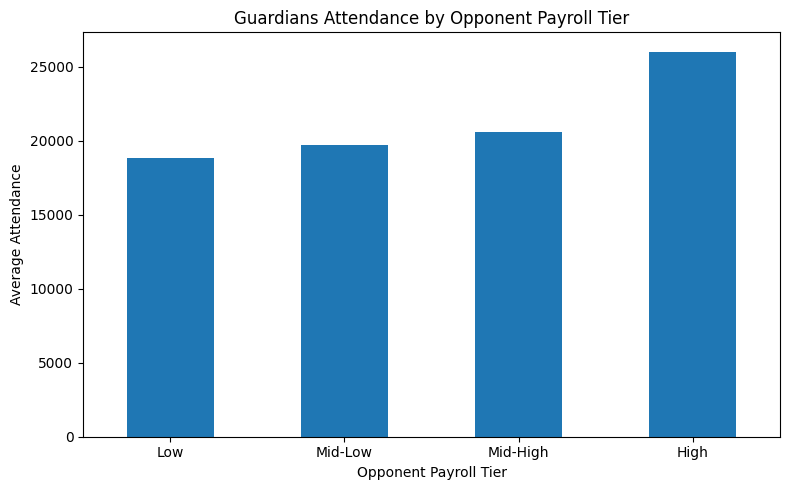

In [43]:
import matplotlib.pyplot as plt

payroll_tier_avg = (
    guardians_home_games
    .groupby("opponent_payroll_tier")["attendance"]
    .mean()
    .reindex(["Low", "Mid-Low", "Mid-High", "High"])
)

plt.figure(figsize=(8, 5))
payroll_tier_avg.plot(kind="bar")
plt.title("Guardians Attendance by Opponent Payroll Tier")
plt.xlabel("Opponent Payroll Tier")
plt.ylabel("Average Attendance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
import plotly.express as px

# Create team-level dataset
team_summary = (
    mlb_home_games
    .groupby(['team_abbr', 'team', 'season'])
    .agg(
        avg_attendance=('attendance', 'mean'),
        payroll=('team_payroll', 'mean')
    )
    .reset_index()
)

fig = px.scatter(
    team_summary,
    x="payroll",
    y="avg_attendance",
    color="team_abbr",
    hover_name="team",

    title="MLB Team Payroll vs Average Attendance"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Team Payroll",
    yaxis_title="Average Attendance",
    font=dict(size=16),
    width=900,
    height=550
)

fig.update_xaxes(tickformat=",.0f")
fig.update_yaxes(tickformat=",.0f")

fig.show()

In [45]:
stadium_capacity = pd.DataFrame({
    "team_abbr": [
        "CLE","NYA","LAN","CHN","BOS","ATL","HOU","SFN","SEA","TEX",
        "PHI","NYN","SDN","TOR","STL","MIL","MIN","DET","COL","ARI",
        "MIA","TBA","KCA","PIT","CIN","BAL","WAS","OAK","LAA","CHA"
    ],
    "capacity": [
        34830, 46537, 56000, 41649, 37755, 41084, 41168, 41915, 47929, 40300,
        42792, 41922, 40209, 49282, 45494, 41900, 38544, 41083, 50144, 48633,
        36742, 25025, 37903, 38747, 42319, 45971, 41339, 46847, 45517, 40615
    ]
})

In [46]:
mlb_home_games = mlb_home_games.merge(
    stadium_capacity,
    on="team_abbr",
    how="left"
)

In [47]:
mlb_home_games["attendance_pct"] = (
    mlb_home_games["attendance"] / mlb_home_games["capacity"]
)

In [48]:
mlb_home_games["attendance_pct"] = (
    mlb_home_games["attendance"] / mlb_home_games["capacity"]
)

In [49]:
mlb_home_games["attendance_pct"] = (
    mlb_home_games["attendance"] / mlb_home_games["capacity"]
)

guardians_home_games = mlb_home_games[mlb_home_games["team_abbr"] == "CLE"].copy()

summary = (
    guardians_home_games
    .groupby("opponent_payroll_tier", observed=False)["attendance_pct"]
    .mean()
    .reindex(["Low", "Mid-Low", "Mid-High", "High"])
    .reset_index()
)

import plotly.express as px

fig = px.bar(
    summary,
    x="opponent_payroll_tier",
    y="attendance_pct",
    text="attendance_pct",
    title="Guardians Stadium Utilization by Opponent Payroll"
)

fig.update_traces(
    texttemplate="%{text:.1%}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    yaxis_tickformat=".0%",
    xaxis_title="Opponent Payroll Tier",
    yaxis_title="Attendance (% of Capacity)"
)

fig.show()

In [50]:
print(mlb_home_games.columns.tolist())

['game_date', 'season', 'team_abbr', 'team', 'opponent_abbr', 'result', 'attendance', 'weekday', 'month', 'weekend_game', 'day_night', 'park_id', 'team_payroll', 'opponent_payroll', 'opponent_payroll_tier', 'capacity', 'attendance_pct']


In [51]:
mlb_home_games.rename(columns={"capacity_x": "capacity"}, inplace=True)

In [52]:
import pandas as pd

team_summary = (
    mlb_home_games
    .groupby(["team_abbr", "team", "season"], as_index=False)
    .agg(
        avg_attendance=("attendance", "mean"),
        team_payroll=("team_payroll", "mean"),
        wins=("result", lambda x: (x == "W").sum()),
        losses=("result", lambda x: (x == "L").sum()),
        avg_attendance_pct=("attendance_pct", "mean")
    )
)

team_summary["games"] = team_summary["wins"] + team_summary["losses"]
team_summary["win_pct"] = team_summary["wins"] / team_summary["games"]

# Add a column to identify the Guardians
team_summary['is_guardians'] = team_summary['team_abbr'] == 'CLE'

team_summary.head()

,team_abbr,team,season,avg_attendance,team_payroll,wins,losses,avg_attendance_pct,games,win_pct,is_guardians
0,ANA,Los Angeles Angels,2021,18484.012195,196428336.0,40,42,NaN,82,0.487805,False
1,ANA,Los Angeles Angels,2022,30339.024691,191581966.0,40,41,NaN,81,0.493827,False
2,ANA,Los Angeles Angels,2023,32599.691358,231476965.0,38,43,NaN,81,0.469136,False
3,ANA,Los Angeles Angels,2024,31822.185185,193150799.0,32,49,NaN,81,0.395062,False
4,ANA,Los Angeles Angels,2025,32290.197531,230062125.0,39,42,NaN,81,0.481481,False


In [53]:
import plotly.express as px

fig = px.scatter(
    team_summary,
    x="team_payroll",
    y="win_pct",
    hover_name="team",
    hover_data=["season", "wins", "losses"],
    trendline="ols",
    title="MLB Team Payroll vs Win Percentage"
)

fig.update_traces(marker=dict(size=10))

fig.update_layout(
    template="plotly_white",
    width=950,
    height=550,
    font=dict(size=16),
    xaxis_title="Team Payroll",
    yaxis_title="Win Percentage",
    title={
        "text": "MLB Team Payroll vs Win Percentage",
        "x": 0.5,
        "xanchor": "center"
    }
)

fig.update_xaxes(tickformat=",.0f")
fig.update_yaxes(tickformat=".0%")

fig.show()

In [54]:
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.formula.api as smf # Import statsmodels for OLS

fig = px.scatter(
    team_summary,
    x="win_pct",
    y="avg_attendance_pct",
    color="is_guardians", # Color by the new column
    color_discrete_map={True: 'red', False: 'grey'}, # Explicitly define colors
    hover_name="team",
    hover_data=["season", "wins", "losses", "avg_attendance"],
    title="MLB Win Percentage vs Average Home Attendance Percentage"
)

# Calculate OLS trendline for non-Guardians (is_guardians == False)
non_guardians_df = team_summary[team_summary['is_guardians'] == False]

if not non_guardians_df.empty:
    ols_model = smf.ols(
        formula='avg_attendance_pct ~ win_pct',
        data=non_guardians_df
    ).fit()
    trendline_x = non_guardians_df['win_pct']
    trendline_y = ols_model.predict(non_guardians_df['win_pct'])

    # Add the trendline as a new trace
    fig.add_trace(
        go.Scatter(
            x=trendline_x,
            y=trendline_y,
            mode='lines',
            name='OLS Trend (Other Teams)',
            line=dict(color='blue', dash='dash'), # Match color of non-Guardians
            showlegend=True
        )
    )

fig.update_traces(marker=dict(size=10))

fig.update_layout(
    template="plotly_white",
    width=950,
    height=550,
    font=dict(size=16),
    xaxis_title="Win Percentage",
    yaxis_title="Average Home Attendance Percentage",
    title={
        "text": "MLB Win Percentage vs Average Home Attendance Percentage",
        "x": 0.5,
        "xanchor": "center"
    }
)

fig.update_xaxes(tickformat=".0%")
fig.update_yaxes(tickformat=".0%")

fig.show()

In [55]:
fig = px.scatter(
    team_summary,
    x="team_payroll",
    y="win_pct",
    color="is_guardians",
    color_discrete_map={True: "red", False: "gray"},
    hover_name="team",
    hover_data=["season", "wins", "losses"],
    trendline="ols",
    title="MLB Team Payroll vs Win Percentage (Guardians Highlighted)"
)

fig.update_traces(marker=dict(size=10))

fig.update_layout(
    template="plotly_white",
    width=950,
    height=550,
    font=dict(size=16),
    xaxis_title="Team Payroll",
    yaxis_title="Win Percentage",
    title={
        "text": "MLB Team Payroll vs Win Percentage (Guardians Highlighted)",
        "x": 0.5
    }
)

fig.update_xaxes(tickformat=",.0f")
fig.update_yaxes(tickformat=".0%")

fig.show()

In [56]:
import pandas as pd
import plotly.express as px

# Create win % tiers
team_summary["win_pct_tier"] = pd.qcut(
    team_summary["win_pct"],
    4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

# Aggregate attendance
win_attendance = (
    team_summary
    .groupby("win_pct_tier", observed=False)["avg_attendance"]
    .mean()
    .reindex(["Low", "Mid-Low", "Mid-High", "High"])
    .reset_index()
)

# Plot
fig = px.bar(
    win_attendance,
    x="win_pct_tier",
    y="avg_attendance",
    text="avg_attendance",
    title="Average Attendance by Team Performance Tier"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=550,
    font=dict(size=16),
    xaxis_title="Win Percentage Tier",
    yaxis_title="Average Attendance"
)

fig.update_yaxes(tickformat=",.0f")

fig.show()

In [57]:
bins = team_summary["win_pct"].quantile([0, .25, .5, .75, 1]).values

labels = [
    f"<{bins[1]:.3f}",
    f"{bins[1]:.3f}–{bins[2]:.3f}",
    f"{bins[2]:.3f}–{bins[3]:.3f}",
    f">{bins[3]:.3f}"
]

team_summary["win_pct_tier"] = pd.qcut(
    team_summary["win_pct"],
    4,
    labels=labels
)

In [58]:
pivot = guardians_home_games.pivot_table(
    values="attendance",
    index="month",
    columns="weekday",
    aggfunc="mean"
)
month_order = ["April", "May", "June", "July", "August", "September", "October"]
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot = pivot.reindex(index=month_order, columns=weekday_order)

fig = px.imshow(
    pivot,
    text_auto=True,
    aspect="auto",
    title="Guardians Average Attendance by Month and Weekday"
)

fig.update_layout(template="plotly_white")
fig.show()

In [59]:
import pandas as pd
import plotly.express as px

# Choose comparison team(s)
comparison_teams_abbr = ["MIL", "SEA"] # Brewers and Mariners
comparison_team_names = {
    "MIL": "Milwaukee Brewers",
    "SEA": "Seattle Mariners"
}

# Keep only Guardians + comparison team(s)
dome_compare = mlb_home_games[
    mlb_home_games["team_abbr"].isin(["CLE"] + comparison_teams_abbr)
].copy()

# Make sure attendance_pct exists
dome_compare["attendance_pct"] = dome_compare["attendance"] / dome_compare["capacity"]

# Optional: prevent weird values over 100%
dome_compare["attendance_pct"] = dome_compare["attendance_pct"].clip(upper=1)

# Month order
month_order = ["April", "May", "June", "July", "August", "September", "October"]
dome_compare["month"] = pd.Categorical(
    dome_compare["month"],
    categories=month_order,
    ordered=True
)

# Average attendance % by month and team
monthly_compare = (
    dome_compare
    .groupby(["team", "month"], as_index=False)["attendance_pct"]
    .mean()
    .dropna()
)

monthly_compare.head(40)

/tmp/ipykernel_19372/2567428933.py:33: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,team,month,attendance_pct
0,Cleveland Guardians,April,0.432087
1,Cleveland Guardians,May,0.515064
2,Cleveland Guardians,June,0.621710
3,Cleveland Guardians,July,0.725871
4,Cleveland Guardians,August,0.651666
5,Cleveland Guardians,September,0.586005
6,Cleveland Guardians,October,0.566925
7,Milwaukee Brewers,April,0.558173
8,Milwaukee Brewers,May,0.620647
9,Milwaukee Brewers,June,0.700045


In [79]:
import plotly.express as px
import math

mlb_home_games["attendance_pct"] = (
    mlb_home_games["attendance"] / mlb_home_games["capacity"]
)

guardians_home_games = mlb_home_games[mlb_home_games["team_abbr"] == "CLE"].copy()

tier_order = ["Low", "Mid-Low", "Mid-High", "High"]

summary = (
    guardians_home_games
    .groupby("opponent_payroll_tier", observed=False)["attendance_pct"]
    .mean()
    .reindex(tier_order)
    .reset_index()
)

# Change this if your opponent column has a different name
opponent_col = "opponent_abbr"

teams_by_tier = (
    guardians_home_games
    .groupby("opponent_payroll_tier", observed=False)[opponent_col]
    .unique()
    .reindex(tier_order)
)

# ESPN logo abbreviations differ for a few MLB teams
espn_logo_abbr = {
    "ARI": "ari", "ATL": "atl", "BAL": "bal", "BOS": "bos", "CHC": "chc",
    "CWS": "chw", "CHW": "chw", "CIN": "cin", "CLE": "cle", "COL": "col",
    "DET": "det", "HOU": "hou", "KC": "kc", "KCR": "kc", "LAA": "laa",
    "LAD": "lad", "MIA": "mia", "MIL": "mil", "MIN": "min", "NYM": "nym",
    "NYY": "nyy", "ATH": "ath", "OAK": "ath", "PHI": "phi", "PIT": "pit",
    "SD": "sd", "SDP": "sd", "SEA": "sea", "SF": "sf", "SFG": "sf",
    "STL": "stl", "TB": "tb", "TBR": "tb", "TEX": "tex", "TOR": "tor",
    "WSH": "wsh", "WAS": "wsh"
}

def logo_url(team):
    abbr = espn_logo_abbr.get(team, team.lower())
    return f"https://a.espncdn.com/i/teamlogos/mlb/500/{abbr}.png"

fig = px.bar(
    summary,
    x="opponent_payroll_tier",
    y="attendance_pct",
    text="attendance_pct",
    title="Guardians Stadium Utilization by Opponent Payroll",
    category_orders={"opponent_payroll_tier": tier_order}
)

fig.update_traces(
    texttemplate="%{text:.1%}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    yaxis_tickformat=".0%",
    xaxis_title="Opponent Payroll Tier",
    yaxis_title="Attendance (% of Capacity)",
    yaxis_range=[0, max(summary["attendance_pct"]) + 0.15]
)

# Add logos inside each bar
n_tiers = len(tier_order)

for i, tier in enumerate(tier_order):
    teams = list(teams_by_tier.loc[tier]) if tier in teams_by_tier.index else []
    teams = [t for t in teams if isinstance(t, str)]

    if not teams:
        continue

    bar_height = summary.loc[
        summary["opponent_payroll_tier"] == tier,
        "attendance_pct"
    ].iloc[0]

    cols = min(4, len(teams))
    rows = math.ceil(len(teams) / cols)

    x_center = (i + 0.5) / n_tiers
    logo_size = 0.099
    x_gap = 0.05
    y_gap = 0.1

    start_x = x_center - ((cols - 1) * x_gap) / 2
    start_y = min(bar_height - 0.08, 0.62)

    for j, team in enumerate(teams):
        row = j // cols
        col = j % cols

        fig.add_layout_image(
            dict(
                source=logo_url(team),
                xref="paper",
                yref="y",
                x=start_x + col * x_gap,
                y=start_y - row * y_gap,
                sizex=logo_size,
                sizey=logo_size,
                xanchor="center",
                yanchor="middle",
                layer="above"
            )
        )

fig.show()


In [89]:
import plotly.express as px

team_label_map = {
    "Cleveland Guardians": "Guardians",
    comparison_team_names["MIL"]: "Brewers",
    comparison_team_names["SEA"]: "Mariners"
}

team_colors = {
    "Guardians": "#FF0000",
    "Brewers": "#FFC52F",
    "Mariners": "#005C5C"
}

monthly_plot = (
    monthly_compare
    .assign(team_label=lambda d: d["team"].map(team_label_map))
    .dropna(subset=["team_label"])
    .copy()
)

fig = px.line(
    monthly_plot,
    x="month",
    y="attendance_pct",
    color="team_label",
    markers=True,
    category_orders={"month": month_order},
    color_discrete_map=team_colors,
    title="Monthly Home Attendance Utilization"
)

fig.update_traces(
    line=dict(width=4),
    marker=dict(size=10, line=dict(width=2, color="white"))
)

fig.update_layout(
    template="plotly_white",
    width=950,
    height=560,
    font=dict(size=15, color="#26364D"),
    title={
        "text": "Monthly Home Attendance Utilization<br><sup>Guardians vs Brewers vs Mariners</sup>",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Month",
    yaxis_title="Attendance (% of Capacity)",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.03,
        xanchor="center",
        x=0.5
    ),
    legend_title_text="",
    margin=dict(t=110, r=70, b=70, l=85),
    hovermode="x unified"
)

fig.update_yaxes(
    tickformat=".0%",
    range=[0.40, 0.85],
    gridcolor="#E8EDF4"
)

fig.update_xaxes(
    gridcolor="#EEF2F7"
)

fig.show()


In [88]:
last_points = (
    monthly_plot
    .sort_values("month", key=lambda s: s.map({m: i for i, m in enumerate(month_order)}))
    .groupby("team_label")
    .tail(1)
)

for _, row in last_points.iterrows():
    fig.add_annotation(
        x=row["month"],
        y=row["attendance_pct"],
        text=f"{row['team_label']} {row['attendance_pct']:.1%}",
        showarrow=True,

        font=dict(
            size=14,
            color=team_colors[row["team_label"]]
        )
    )

fig.update_layout(showlegend=False)
fig.show()


In [97]:
guardians_home_games["attendance_pct"] = (
    guardians_home_games["attendance"] / guardians_home_games["capacity"]
)

pivot_pct = guardians_home_games.pivot_table(
    values="attendance_pct",
    index="month",
    columns="weekday",
    aggfunc="mean"
).reindex(index=month_order, columns=weekday_order)

fig = px.imshow(
    pivot_pct,
    text_auto=False,
    aspect="auto",
    color_continuous_scale="RdYlGn",
    title="Guardians Stadium Utilization by Month and Weekday",
    labels=dict(
        x="Weekday",
        y="Month",
        color="Capacity Used"
    )
)

fig.update_traces(
    text=pivot_pct.map(lambda v: "" if pd.isna(v) else f"{v:.0%}"),
    texttemplate="%{text}",
    hovertemplate=(
        "<b>%{y}</b><br>"
        "%{x}<br>"
        "Capacity used: %{z:.1%}<extra></extra>"
    ),
    xgap=3,
    ygap=3
)

fig.update_layout(
    template="plotly_white",
    width=1000,
    height=520,
    font=dict(size=14, color="#26364D"),
    title={
        "text": "Guardians Stadium Utilization by Month and Weekday",
        "x": 0.5,
        "xanchor": "center"
    }
)

fig.update_xaxes(side="bottom")
fig.update_yaxes(autorange="reversed")

fig.show()


In [95]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.formula.api as smf

plot_df = team_summary.copy()

plot_df["team_group"] = np.where(
    plot_df["is_guardians"],
    "Guardians",
    "Other MLB Teams"
)

fig = px.scatter(
    plot_df,
    x="win_pct",
    y="avg_attendance_pct",
    color="team_group",
    color_discrete_map={
        "Guardians": "#E31937",
        "Other MLB Teams": "#8A8F98"
    },
    symbol="team_group",
    symbol_map={
        "Guardians": "star",
        "Other MLB Teams": "circle"
    },
    hover_name="team",
    hover_data={
        "team_group": False,
        "season": True,
        "wins": True,
        "losses": True,
        "win_pct": ":.1%",
        "avg_attendance_pct": ":.1%",
        "avg_attendance": ":,.0f"
    },
    title="Winning Helps Attendance, But It Does Not Explain Everything"
)

fig.update_traces(
    marker=dict(
        size=9,
        line=dict(width=0.5, color="white")
    ),
    selector=dict(name="Other MLB Teams"),
    opacity=0.55
)

fig.update_traces(
    marker=dict(
        size=15,
        line=dict(width=1.5, color="white")
    ),
    selector=dict(name="Guardians")
)

# OLS trendline for non-Guardians
non_guardians_df = plot_df[~plot_df["is_guardians"]].dropna(
    subset=["win_pct", "avg_attendance_pct"]
)

if not non_guardians_df.empty:
    ols_model = smf.ols(
        formula="avg_attendance_pct ~ win_pct",
        data=non_guardians_df
    ).fit()

    x_min = non_guardians_df["win_pct"].min()
    x_max = non_guardians_df["win_pct"].max()
    trendline_x = np.linspace(x_min, x_max, 100)

    trendline_df = pd.DataFrame({"win_pct": trendline_x})
    trendline_y = ols_model.predict(trendline_df)

    fig.add_trace(
        go.Scatter(
            x=trendline_x,
            y=trendline_y,
            mode="lines",
            name=f"League trend, excluding Guardians",
            line=dict(color="#26364D", width=3, dash="dash"),
            hoverinfo="skip"
        )
    )

    slope = ols_model.params["win_pct"]
    intercept = ols_model.params["Intercept"]
    r2 = ols_model.rsquared

    fig.add_annotation(
        x=0.31,
        y=0.98,
        xref="paper",
        yref="paper",
        text=f"Other teams trend: attendance = {intercept:.2f} + {slope:.2f} × win pct<br>R² = {r2:.2f}",
        showarrow=False,
        align="left",
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="#D8DEE9",
        borderwidth=1,
        font=dict(size=13, color="#26364D")
    )

# Label Guardians seasons
guardians_points = plot_df[plot_df["is_guardians"]]

for _, row in guardians_points.iterrows():
    fig.add_annotation(
        x=row["win_pct"],
        y=row["avg_attendance_pct"],
        text=str(row["season"]),
        showarrow=False,
        yshift=18,
        font=dict(size=13, color="#E31937")
    )

# Reference lines
league_avg_win = non_guardians_df["win_pct"].mean()
league_avg_att = non_guardians_df["avg_attendance_pct"].mean()

fig.add_vline(
    x=league_avg_win,
    line_width=1,
    line_dash="dot",
    line_color="#A7B0BE",
    annotation_text="League avg win %",
    annotation_position="bottom right"
)

fig.add_hline(
    y=league_avg_att,
    line_width=1,
    line_dash="dot",
    line_color="#A7B0BE",
    annotation_text="League avg attendance %",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    width=980,
    height=600,
    font=dict(size=15, color="#26364D"),
    title={
        "text": "Winning Helps Attendance, But It Does Not Explain Everything<br><sup>Guardians seasons compared with other MLB team-seasons</sup>",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Win Percentage",
    yaxis_title="Average Home Attendance (% of Capacity)",
    legend_title_text="",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.03,
        xanchor="center",
        x=0.5
    ),
    margin=dict(t=120, r=80, b=70, l=90)
)

fig.update_xaxes(
    tickformat=".0%",
    gridcolor="#E8EDF4"
)

fig.update_yaxes(
    tickformat=".0%",
    gridcolor="#E8EDF4"
)

fig.show()


In [104]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.formula.api as smf

plot_df = team_summary.copy()

plot_df["team_group"] = np.where(
    plot_df["is_guardians"],
    "Guardians",
    "Other MLB Teams"
)

# Payroll in millions is easier to read
plot_df["payroll_m"] = plot_df["team_payroll"] / 1_000_000

# Fit one league-wide trendline
model_df = plot_df.dropna(subset=["payroll_m", "win_pct"])

ols_model = smf.ols(
    formula="win_pct ~ payroll_m",
    data=model_df
).fit()

plot_df["expected_win_pct"] = ols_model.predict(plot_df[["payroll_m"]])
plot_df["win_pct_vs_expected"] = plot_df["win_pct"] - plot_df["expected_win_pct"]

plot_df["performance"] = np.select(
    [
        plot_df["win_pct_vs_expected"] >= 0.05,
        plot_df["win_pct_vs_expected"] <= -0.05
    ],
    [
        "Overperformed payroll",
        "Underperformed payroll"
    ],
    default="Near expectation"
)

fig = px.scatter(
    plot_df,
    x="payroll_m",
    y="win_pct",
    color="performance",
    symbol="team_group",
    symbol_map={
        "Guardians": "star",
        "Other MLB Teams": "circle"
    },
    color_discrete_map={
        "Overperformed payroll": "#1A936F",
        "Near expectation": "#8A8F98",
        "Underperformed payroll": "#D1495B"
    },
    hover_name="team",
    hover_data={
        "season": True,
        "wins": True,
        "losses": True,
        "payroll_m": ":.1f",
        "win_pct": ":.1%",
        "expected_win_pct": ":.1%",
        "win_pct_vs_expected": ":.1%",
        "team_group": False,
        "performance": False
    },
    title="Payroll Buys Wins, But Efficiency Varies"
)

fig.update_traces(
    marker=dict(
        size=10,
        line=dict(width=0.6, color="white")
    ),
    opacity=0.65
)

fig.update_traces(
    marker=dict(
        size=17,
        line=dict(width=1.5, color="white")
    ),
    selector=dict(marker_symbol="star")
)

# Smooth trendline
x_line = np.linspace(model_df["payroll_m"].min(), model_df["payroll_m"].max(), 100)
line_df = pd.DataFrame({"payroll_m": x_line})
y_line = ols_model.predict(line_df)

fig.add_trace(
    go.Scatter(
        x=x_line,
        y=y_line,
        mode="lines",
        name="Expected win % from payroll",
        line=dict(color="#26364D", width=3, dash="dash"),
        hoverinfo="skip"
    )
)

# Label Guardians points by season
guardians_points = plot_df[plot_df["is_guardians"]]

for _, row in guardians_points.iterrows():
    fig.add_annotation(
        x=row["payroll_m"],
        y=row["win_pct"],
        text=str(row["season"]),
        showarrow=False,
        yshift=18,
        font=dict(size=13, color="#E31937")
    )

fig.update_layout(
    template="plotly_white",
    width=980,
    height=600,
    font=dict(size=15, color="#26364D"),
    title={
        "text": "Payroll Buys Wins, But Efficiency Varies<br><sup>Guardians seasons highlighted against MLB team-seasons</sup>",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Team Payroll, USD Millions",
    yaxis_title="Win Percentage",
    legend_title_text="",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.03,
        xanchor="center",
        x=0.5
    ),
    margin=dict(t=120, r=80, b=70, l=90),
    hovermode="closest"
)

fig.update_xaxes(
    tickprefix="$",
    ticksuffix="M",
    gridcolor="#E8EDF4"
)

fig.update_yaxes(
    tickformat=".0%",
    gridcolor="#E8EDF4"
)
# Clean up legend labels
for trace in fig.data:
    if trace.name == "Overperformed payroll, Other MLB Teams":
        trace.name = "Overperformed payroll"
    elif trace.name == "Near expectation, Other MLB Teams":
        trace.name = "Near expectation"
    elif trace.name == "Underperformed payroll, Other MLB Teams":
        trace.name = "Underperformed payroll"
    elif "Guardians" in trace.name and trace.mode == "markers":
        trace.showlegend = False

fig.show()


In [102]:
fig.update_layout(
    template="plotly_white",
    width=980,
    height=640,
    font=dict(size=15, color="#26364D"),
    title={
        "text": "Payroll Buys Wins, But Efficiency Varies<br><sup>Guardians seasons highlighted against MLB team-seasons</sup>",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Team Payroll, USD Millions",
    yaxis_title="Win Percentage",
    legend_title_text="",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        bgcolor="rgba(255,255,255,0.85)"
    ),
    margin=dict(t=155, r=80, b=70, l=90),
    hovermode="closest"
)


In [119]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.formula.api as smf

plot_df = team_summary.copy()

plot_df["payroll_m"] = plot_df["team_payroll"] / 1_000_000

model_df = plot_df.dropna(subset=["payroll_m", "win_pct"]).copy()

ols_model = smf.ols(
    formula="win_pct ~ payroll_m",
    data=model_df
).fit()

plot_df["expected_win_pct"] = ols_model.predict(plot_df[["payroll_m"]])
plot_df["win_pct_vs_expected"] = plot_df["win_pct"] - plot_df["expected_win_pct"]

plot_df["performance"] = np.select(
    [
        plot_df["win_pct_vs_expected"] >= 0.05,
        plot_df["win_pct_vs_expected"] <= -0.05
    ],
    [
        "Overperformed payroll",
        "Underperformed payroll"
    ],
    default="Near expectation"
)

non_guardians = plot_df[~plot_df["is_guardians"]].copy()
guardians = plot_df[plot_df["is_guardians"]].copy()

fig = px.scatter(
    non_guardians,
    x="payroll_m",
    y="win_pct",
    color="performance",
    color_discrete_map={
        "Overperformed payroll": "#1A936F",
        "Near expectation": "#8A8F98",
        "Underperformed payroll": "#D1495B"
    },
    hover_name="team",
    hover_data={
        "season": True,
        "wins": True,
        "losses": True,
        "payroll_m": ":.1f",
        "win_pct": ":.1%",
        "expected_win_pct": ":.1%",
        "win_pct_vs_expected": ":.1%",
        "performance": False
    },
    title="Payroll Buys Wins, But Efficiency Varies"
)

fig.update_traces(
    marker=dict(
        size=10,
        line=dict(width=0.6, color="white")
    ),
    opacity=0.65
)

# Guardians highlighted separately so the legend stays clean
fig.add_trace(
    go.Scatter(
        x=guardians["payroll_m"],
        y=guardians["win_pct"],
        mode="markers",
        name="Guardians",
        marker=dict(
            symbol="star",
            size=18,
            color="#0000FF", # Changed color to blue
            line=dict(width=1.5, color="white")
        ),
        customdata=guardians[
            ["season", "wins", "losses", "payroll_m", "expected_win_pct", "win_pct_vs_expected"]
        ],
        text=guardians["team"],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Season: %{customdata[0]}<br>"
            "Wins: %{customdata[1]}<br>"
            "Losses: %{customdata[2]}<br>"
            "Payroll: $%{customdata[3]:.1f}M<br>"
            "Win pct: %{y:.1%}<br>"
            "Expected win pct: %{customdata[4]:.1%}<br>"
            "Vs expected: %{customdata[5]:+.1%}"
            "<extra></extra>"
        )
    )
)

# Smooth OLS trendline
x_line = np.linspace(model_df["payroll_m"].min(), model_df["payroll_m"].max(), 100)
line_df = pd.DataFrame({"payroll_m": x_line})
y_line = ols_model.predict(line_df)

fig.add_trace(
    go.Scatter(
        x=x_line,
        y=y_line,
        mode="lines",
        name="Expected win % from payroll",
        line=dict(color="#26364D", width=3, dash="dash"),
        hoverinfo="skip"
    )
)

# Label Guardians seasons
for _, row in guardians.iterrows():
    fig.add_annotation(
        x=row["payroll_m"],
        y=row["win_pct"],
        text=str(row["season"]),
        showarrow=False,
        yshift=18,
        font=dict(size=13, color="#0000FF") # Changed annotation color to blue as well
    )

fig.update_layout(
    template="plotly_white",
    width=980,
    height=640,
    font=dict(size=15, color="#26364D"),
    title={
        "text": "Payroll Buys Wins, But Efficiency Varies<br><sup>Guardians seasons highlighted against MLB team-seasons</sup>",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Team Payroll, USD Millions",
    yaxis_title="Win Percentage",
    legend_title_text="",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.45,
        xanchor="center",
        x=0.5,
        bgcolor="rgba(255,255,255,0.85)"
    ),
    margin=dict(t=145, r=80, b=70, l=90),
    hovermode="closest"
)

fig.update_xaxes(
    tickprefix="$",
    ticksuffix="M",
    gridcolor="#E8EDF4"
)

fig.update_yaxes(
    tickformat=".0%",
    gridcolor="#E8EDF4"
)

fig.show()


In [123]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.formula.api as smf

plot_df = team_summary.copy()

plot_df["team_group"] = np.where(
    plot_df["is_guardians"],
    "Guardians",
    "Other MLB Teams"
)

non_guardians_df = plot_df[~plot_df["is_guardians"]].dropna(
    subset=["win_pct", "avg_attendance_pct"]
)

guardians_df = plot_df[plot_df["is_guardians"]].dropna(
    subset=["win_pct", "avg_attendance_pct"]
)

fig = px.scatter(
    non_guardians_df,
    x="win_pct",
    y="avg_attendance_pct",
    color_discrete_sequence=["#8A8F98"],
    hover_name="team",
    hover_data={
        "season": True,
        "wins": True,
        "losses": True,
        "avg_attendance": ":,.0f",
        "win_pct": ":.1%",
        "avg_attendance_pct": ":.1%"
    },
    title="MLB Win Percentage vs Average Home Attendance Percentage"
)

fig.update_traces(
    name="Other MLB Teams",
    marker=dict(
        size=9,
        color="#8A8F98",
        line=dict(width=0.5, color="white")
    ),
    opacity=0.6,
    showlegend=True
)

# Add Guardians as blue highlighted points
fig.add_trace(
    go.Scatter(
        x=guardians_df["win_pct"],
        y=guardians_df["avg_attendance_pct"],
        mode="markers",
        name="Guardians",
        marker=dict(
            size=15,
            color="#00385D",
            symbol="star",
            line=dict(width=1.5, color="white")
        ),
        text=guardians_df["team"],
        customdata=guardians_df[["season", "wins", "losses", "avg_attendance"]],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Season: %{customdata[0]}<br>"
            "Wins: %{customdata[1]}<br>"
            "Losses: %{customdata[2]}<br>"
            "Average attendance: %{customdata[3]:,.0f}<br>"
            "Win percentage: %{x:.1%}<br>"
            "Attendance percentage: %{y:.1%}"
            "<extra></extra>"
        )
    )
)

# Smooth OLS trendline for other MLB teams
if not non_guardians_df.empty:
    ols_model = smf.ols(
        formula="avg_attendance_pct ~ win_pct",
        data=non_guardians_df
    ).fit()

    trendline_x = np.linspace(
        non_guardians_df["win_pct"].min(),
        non_guardians_df["win_pct"].max(),
        100
    )

    trendline_df = pd.DataFrame({"win_pct": trendline_x})
    trendline_y = ols_model.predict(trendline_df)

    fig.add_trace(
        go.Scatter(
            x=trendline_x,
            y=trendline_y,
            mode="lines",
            name="League Trend",
            line=dict(color="#26364D", width=3, dash="dash"),
            hoverinfo="skip"
        )
    )

# Label Guardians seasons
for _, row in guardians_df.iterrows():
    fig.add_annotation(
        x=row["win_pct"],
        y=row["avg_attendance_pct"],
        text=str(row["season"]),
        showarrow=False,
        yshift=16,
        font=dict(size=12, color="#00385D")
    )

fig.update_layout(
    template="plotly_white",
    width=950,
    height=600,
    font=dict(size=15, color="#26364D"),
    title={
        "text": "Winning and Home Attendance<br><sup>Guardians seasons highlighted against other MLB teams</sup>",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Win Percentage",
    yaxis_title="Average Home Attendance (% of Capacity)",
    legend_title_text="",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.03,
        xanchor="center",
        x=0.5
    ),
    margin=dict(t=120, r=70, b=70, l=90),
    hovermode="closest"
)

fig.update_xaxes(
    tickformat=".0%",
    gridcolor="#E8EDF4"
)

fig.update_yaxes(
    tickformat=".0%",
    gridcolor="#E8EDF4"
)

fig.show()
